<a href="https://colab.research.google.com/github/OscarLacomba/proyecto4-estudiantil/blob/main/nyhouse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Numero 4 : Data Wrangling and Visualization Techniques Course


# Descripcion General Del Proyecto :
Utilizando Data Wrangling y Visualizacion de Datos.Se analizara el mercado de inmobiliario en la ciudad de New York, con el objectivo de evaluar para poder indentificar los precios, geografia y otras caracteristicas que influyan en el valor de las propiedades para asesorar a un posible cliente.


# Objetivo :
-Verificacion de relacion entre precios,habitaciones y medidas especificas de la propiedad.

-Observar y analizar la distribucion de la oferta inmobiliaria en los distritos estudiados de la ciudad de New York.

-Optener un resultado con las tecnicas de datos interactivos utilizada.


# Implementacion De Conceptos :
Data Wrangling con Visualizacion de Datos.


# Utilizacion :
-Python 3.x

-Pandas

-Matplotlib

-Seaborn

-Plotly Express

-Google Colab / Jupyter Notebook

-GitHub

Author: Oscar Martinez Gracia
-oskytm@hotmail.com

Curso: Data Science

Created: 2026-03-26

Modified: 2026-04-15

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df = pd.read_csv('/content/NY-House-Dataset.csv')

In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   object 
 1   TYPE                         4801 non-null   object 
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   object 
 7   STATE                        4801 non-null   object 
 8   MAIN_ADDRESS                 4801 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   object 
 10  LOCALITY                     4801 non-null   object 
 11  SUBLOCALITY                  4801 non-null   object 
 12  STREET_NAME                  4801 non-null   object 
 13  LONG_NAME         

,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE
count,4.801000e+03,4801.000000,4801.000000,4801.000000,4801.000000,4801.000000
mean,2.356940e+06,3.356801,2.373861,2184.207862,40.714227,-73.941601
std,3.135525e+07,2.602315,1.946962,2377.140894,0.087676,0.101082
min,2.494000e+03,1.000000,0.000000,230.000000,40.499546,-74.253033
25%,4.990000e+05,2.000000,1.000000,1200.000000,40.639375,-73.987143
50%,8.250000e+05,3.000000,2.000000,2184.207862,40.726749,-73.949189
75%,1.495000e+06,4.000000,3.000000,2184.207862,40.771923,-73.870638
max,2.147484e+09,50.000000,50.000000,65535.000000,40.912729,-73.702450


In [ ]:
# Limpieza de Datos

df_clean_data = df[df['PRICE'] < 20000000].copy()
df_clean_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4747 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4747 non-null   object 
 1   TYPE                         4747 non-null   object 
 2   PRICE                        4747 non-null   int64  
 3   BEDS                         4747 non-null   int64  
 4   BATH                         4747 non-null   float64
 5   PROPERTYSQFT                 4747 non-null   float64
 6   ADDRESS                      4747 non-null   object 
 7   STATE                        4747 non-null   object 
 8   MAIN_ADDRESS                 4747 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4747 non-null   object 
 10  LOCALITY                     4747 non-null   object 
 11  SUBLOCALITY                  4747 non-null   object 
 12  STREET_NAME                  4747 non-null   object 
 13  LONG_NAME              

In [ ]:
# Busqueda por Sublicalidad

sublocality_map = {
    'New York County': 'Manhattan',
    'Kings County': 'Brooklyn',
    'Queens County': 'Queens',
    'Bronx County': 'Bronx',
    'Richmond County': 'Staten Island'
}
df_clean_data['BOROUGH'] = df_clean_data['SUBLOCALITY'].map(sublocality_map)
df_clean_data.head()


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE,BOROUGH
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.0,1400.000000,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483,NaN
2,Brokered by Sowae Corp,House for sale,260000,4,2.0,2015.000000,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109,Staten Island
3,Brokered by COMPASS,Condo for sale,69000,3,1.0,445.000000,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613,Manhattan
5,Brokered by Sowae Corp,House for sale,690000,5,2.0,4004.000000,584 Park Pl,"Brooklyn, NY 11238","584 Park PlBrooklyn, NY 11238",United States,New York,Kings County,Brooklyn,Park Place,"584 Park Pl, Brooklyn, NY 11238, USA",40.674363,-73.958725,Brooklyn
6,Brokered by Douglas Elliman - 575 Madison Ave,Condo for sale,899500,2,2.0,2184.207862,157 W 126th St Unit 1B,"New York, NY 10027","157 W 126th St Unit 1BNew York, NY 10027",New York,New York County,New York,Manhattan,157,"157 W 126th St #1b, New York, NY 10027, USA",40.809448,-73.946777,NaN


In [ ]:
# Filtrar Datos por Distritos Principales

valid_boroughs = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']
df_clean = df_clean_data[df_clean_data['BOROUGH'].isin(valid_boroughs)]
df_clean_data.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE,BOROUGH
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.0,1400.000000,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483,NaN
2,Brokered by Sowae Corp,House for sale,260000,4,2.0,2015.000000,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109,Staten Island
3,Brokered by COMPASS,Condo for sale,69000,3,1.0,445.000000,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613,Manhattan
5,Brokered by Sowae Corp,House for sale,690000,5,2.0,4004.000000,584 Park Pl,"Brooklyn, NY 11238","584 Park PlBrooklyn, NY 11238",United States,New York,Kings County,Brooklyn,Park Place,"584 Park Pl, Brooklyn, NY 11238, USA",40.674363,-73.958725,Brooklyn
6,Brokered by Douglas Elliman - 575 Madison Ave,Condo for sale,899500,2,2.0,2184.207862,157 W 126th St Unit 1B,"New York, NY 10027","157 W 126th St Unit 1BNew York, NY 10027",New York,New York County,New York,Manhattan,157,"157 W 126th St #1b, New York, NY 10027, USA",40.809448,-73.946777,NaN


In [ ]:
# Visualizar Residencias por Precio Pies Cuadrado

df_clean_data['PRICE_PER_SQFT'] = df_clean_data['PRICE'] / df_clean_data['PROPERTYSQFT']
df_clean_data.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE,BOROUGH,PRICE_PER_SQFT
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.0,1400.000000,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483,NaN,225.000000
2,Brokered by Sowae Corp,House for sale,260000,4,2.0,2015.000000,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109,Staten Island,129.032258
3,Brokered by COMPASS,Condo for sale,69000,3,1.0,445.000000,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613,Manhattan,155.056180
5,Brokered by Sowae Corp,House for sale,690000,5,2.0,4004.000000,584 Park Pl,"Brooklyn, NY 11238","584 Park PlBrooklyn, NY 11238",United States,New York,Kings County,Brooklyn,Park Place,"584 Park Pl, Brooklyn, NY 11238, USA",40.674363,-73.958725,Brooklyn,172.327672
6,Brokered by Douglas Elliman - 575 Madison Ave,Condo for sale,899500,2,2.0,2184.207862,157 W 126th St Unit 1B,"New York, NY 10027","157 W 126th St Unit 1BNew York, NY 10027",New York,New York County,New York,Manhattan,157,"157 W 126th St #1b, New York, NY 10027, USA",40.809448,-73.946777,NaN,411.819779


<function matplotlib.pyplot.show(close=None, block=None)>

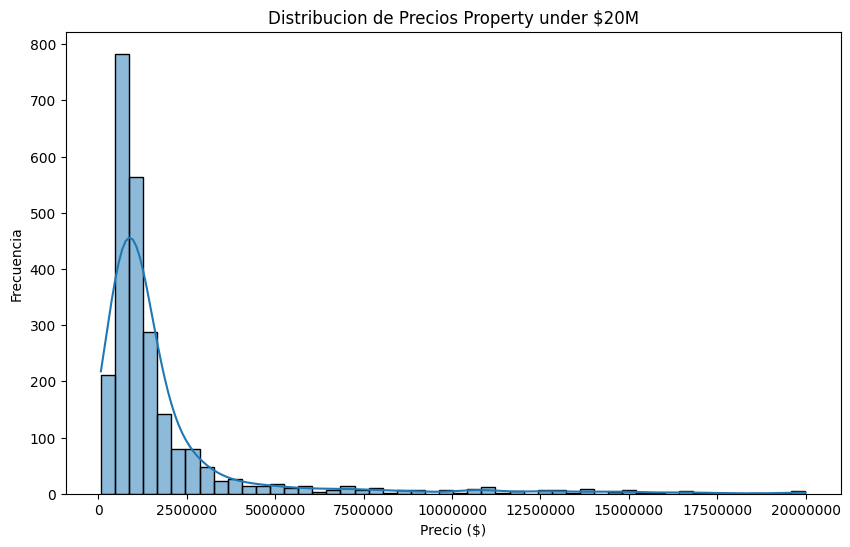

In [ ]:
# Distribución de los precios de las propiedades

plt.figure(figsize=(10, 6))
sns.histplot(df_clean['PRICE'], bins=50, kde=True)
plt.title('Distribucion de Precios Property under $20M')
plt.xlabel('Precio ($)')
plt.ylabel('Frecuencia')
plt.ticklabel_format(style='plain', axis='x')
plt.savefig('price_distribution.png')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

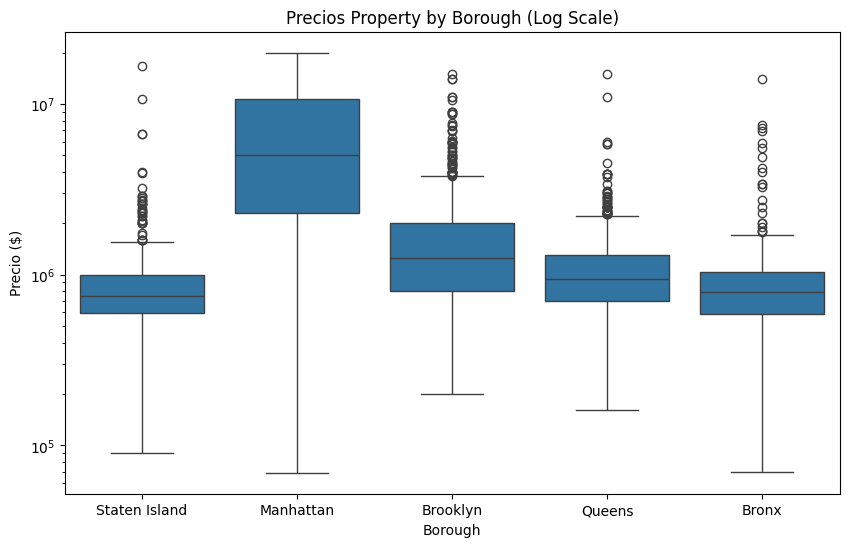

In [ ]:
# Distribución de los precios de las propiedades por distrito

plt.figure(figsize=(10, 6))
sns.boxplot(x='BOROUGH', y='PRICE', data=df_clean)
plt.yscale('log')
plt.title('Precios Property by Borough (Log Scale)')
plt.xlabel('Borough')
plt.ylabel('Precio ($)')
plt.savefig('price_by_borough.png')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

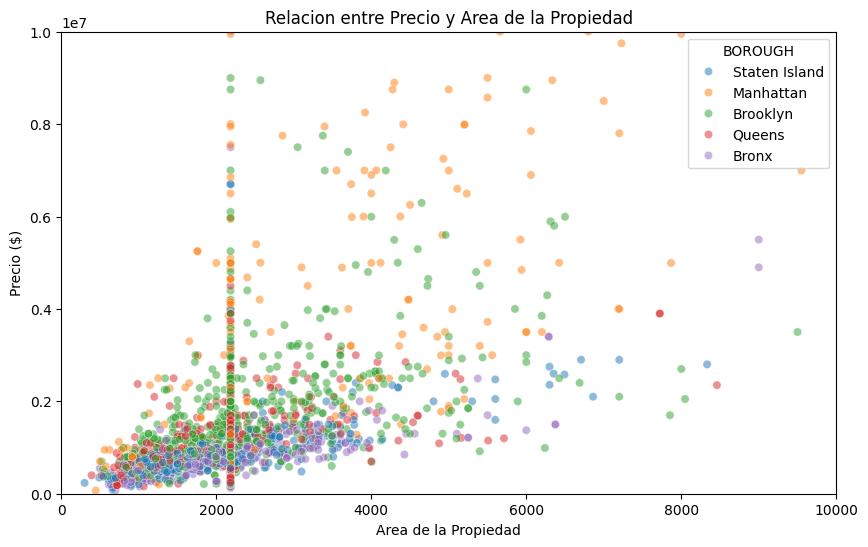

In [ ]:
# Relación entre el precio de las propiedades y su área en pies cuadrados por distrito

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PROPERTYSQFT', y='PRICE', hue='BOROUGH', data=df_clean, alpha=0.5)
plt.xlim(0, 10000)
plt.ylim(0, 10000000)
plt.title('Relacion entre Precio y Area de la Propiedad')
plt.xlabel('Area de la Propiedad')
plt.ylabel('Precio ($)')
plt.savefig('sqft_vs_price.png')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

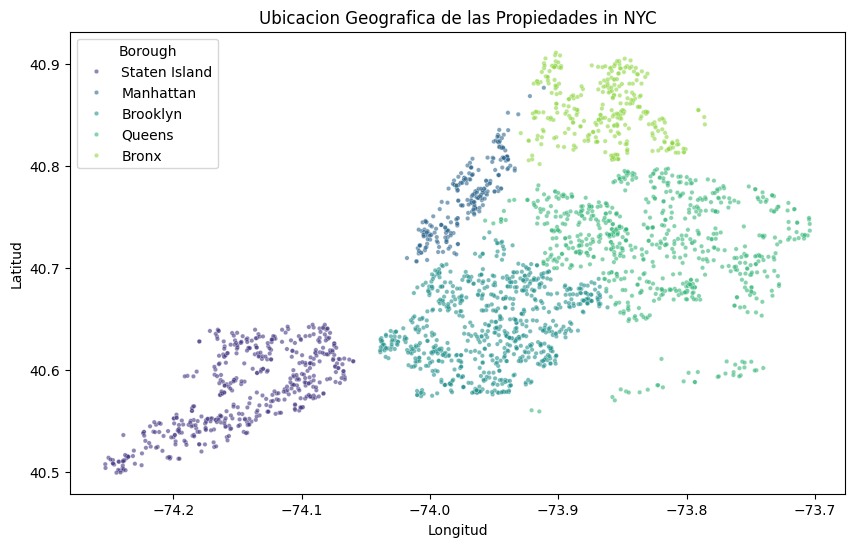

In [ ]:
# Distribución geográfica de las propiedades en la ciudad de Nueva York

plt.figure(figsize=(10, 6))
sns.scatterplot(x='LONGITUDE', y='LATITUDE', hue='BOROUGH', data=df_clean,palette='viridis', s=10, alpha=0.6)
plt.title('Ubicacion Geografica de las Propiedades in NYC')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Borough')
plt.savefig('geopatial_distribution.png')
plt.show

In [ ]:
# Resumen (media, mediana, mínimo y máximo) para los precios y el área de las propiedades, agrupadas por distrito

summary_stats = df_clean.groupby('BOROUGH')[['PRICE', 'PROPERTYSQFT']].agg(['mean', 'median', 'min', 'max'])
summary_stats_sorted = summary_stats.sort_values(('PRICE', 'mean'), ascending=False)
df_clean_data.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE,BOROUGH,PRICE_PER_SQFT
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.0,1400.000000,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483,NaN,225.000000
2,Brokered by Sowae Corp,House for sale,260000,4,2.0,2015.000000,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109,Staten Island,129.032258
3,Brokered by COMPASS,Condo for sale,69000,3,1.0,445.000000,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613,Manhattan,155.056180
5,Brokered by Sowae Corp,House for sale,690000,5,2.0,4004.000000,584 Park Pl,"Brooklyn, NY 11238","584 Park PlBrooklyn, NY 11238",United States,New York,Kings County,Brooklyn,Park Place,"584 Park Pl, Brooklyn, NY 11238, USA",40.674363,-73.958725,Brooklyn,172.327672
6,Brokered by Douglas Elliman - 575 Madison Ave,Condo for sale,899500,2,2.0,2184.207862,157 W 126th St Unit 1B,"New York, NY 10027","157 W 126th St Unit 1BNew York, NY 10027",New York,New York County,New York,Manhattan,157,"157 W 126th St #1b, New York, NY 10027, USA",40.809448,-73.946777,NaN,411.819779


In [ ]:
# Tres mejores propiedades para opcion de compra

top_3_properties = df_clean.sort_values(by='PRICE', ascending=False).head(3)
top_3_properties.head()


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE,BOROUGH
4347,Brokered by Douglas Elliman - 575 Madison Ave,Multi-family home for sale,19995000,7,8.0,8900.0,32 E 22nd St,"New York, NY 10010","32 E 22nd StNew York, NY 10010",United States,New York,New York County,New York,East 22nd Street,"32 E 22nd St, New York, NY 10010, USA",40.739775,-73.987989,Manhattan
1825,Brokered by Serhant,Townhouse for sale,19995000,11,11.0,11110.0,46 Laight St,"New York, NY 10013","46 Laight StNew York, NY 10013",United States,New York,New York County,New York,Laight Street,"46 Laight St, New York, NY 10013, USA",40.722160,-74.007863,Manhattan
3818,Brokered by Serhant,Townhouse for sale,19995000,6,8.0,8757.0,80 Washington Pl,"New York, NY 10011","80 Washington PlNew York, NY 10011",United States,New York,New York County,New York,Washington Place,"80 Washington Pl, New York, NY 10011, USA",40.731888,-73.999989,Manhattan


-El distrito de Manhattan presenta los mayores preciso altos por densidad.

-Brooklyn esta emergiendo como posible distrito con alta reantabilidad, con precios mas accesibles.

-El numeros de pies cuadrados y los baños correlacionan con el precio que el numero de habitaciones en aluguna propiedades de lujo.